<a href="https://colab.research.google.com/github/samarthya04/AD_Lab/blob/main/2205498_Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. KNN Classifier
2. Logistic Regression
3. Bayesian CLassifier
4. Decision Tree

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

In [3]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=200, C=0.5, multi_class='multinomial', solver='lbfgs'),  # Multinomial for multiclass
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier()
}

In [4]:
training_sizes = [0.5, 0.6, 0.7, 0.8, 0.9]
accuracy_results = {clf_name: [] for clf_name in classifiers}
optimal_knn_accuracies = []

In [5]:
optimal_k = None
highest_avg_accuracy = 0
knn_accuracies_by_k = {}

In [6]:
for k in range(3, 10):
    knn_accuracies_by_k[k] = []
    for train_size in training_sizes:
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, stratify=y, random_state=42)
        knn_clf = KNeighborsClassifier(n_neighbors=k)
        knn_clf.fit(X_train, y_train)
        y_pred = knn_clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        knn_accuracies_by_k[k].append(accuracy)

    # Compute the average accuracy for this k
    avg_accuracy = np.mean(knn_accuracies_by_k[k])
    if avg_accuracy > highest_avg_accuracy:
        highest_avg_accuracy = avg_accuracy
        optimal_k = k

In [7]:
for train_size, acc in zip(training_sizes, knn_accuracies_by_k[optimal_k]):
    optimal_knn_accuracies.append(acc)

In [8]:
for train_size in training_sizes:
    for clf_name, clf in classifiers.items():
        # Split the dataset
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, stratify=y, random_state=42)

        # Train the classifier
        clf.fit(X_train, y_train)

        # Predict on the test set
        y_pred = clf.predict(X_test)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_results[clf_name].append(accuracy)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

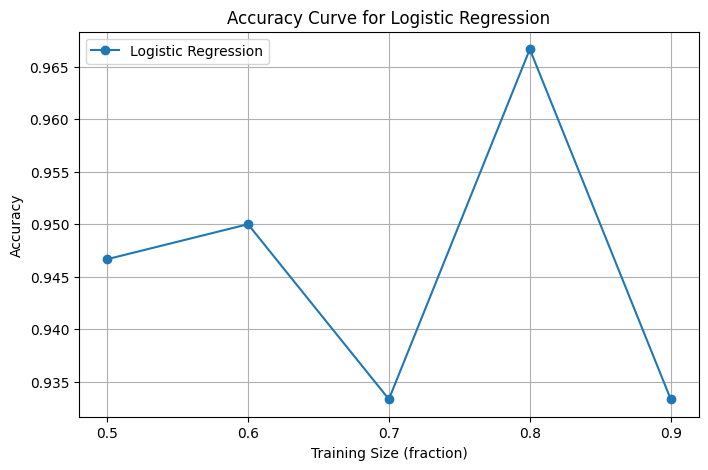

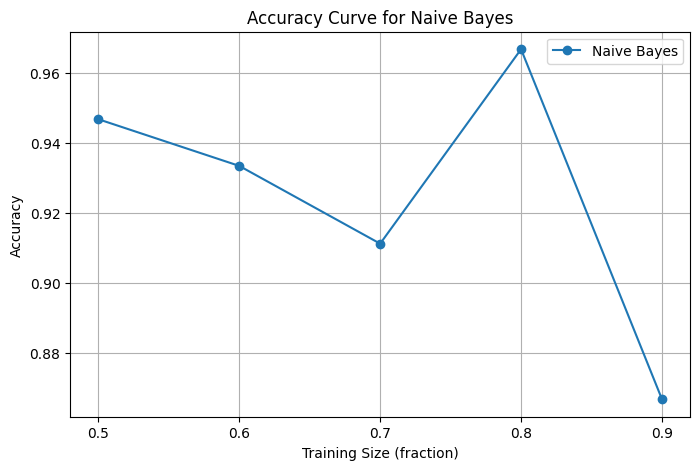

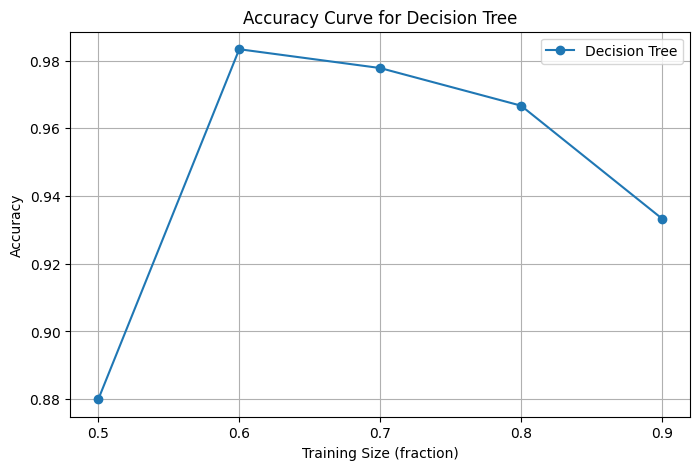

In [9]:
for clf_name, accuracies in accuracy_results.items():
    plt.figure(figsize=(8, 5))
    plt.plot(training_sizes, accuracies, marker='o', label=clf_name)
    plt.title(f'Accuracy Curve for {clf_name}')
    plt.xlabel('Training Size (fraction)')
    plt.ylabel('Accuracy')
    plt.xticks(training_sizes)
    plt.legend()
    plt.grid(True)
    plt.show()

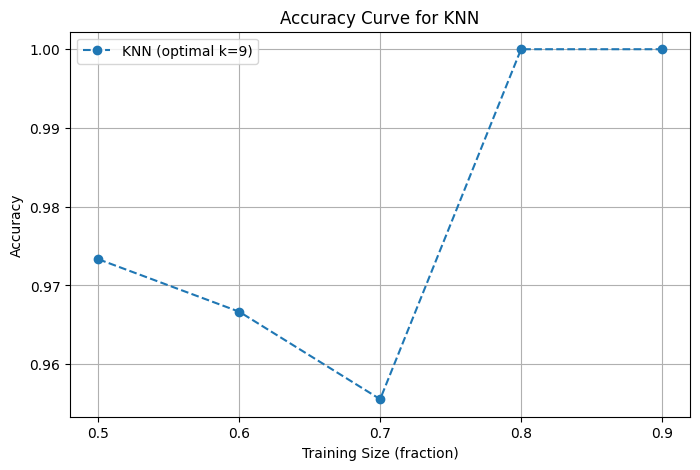

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(training_sizes, optimal_knn_accuracies, marker='o', linestyle='--', label=f'KNN (optimal k={optimal_k})')
plt.title('Accuracy Curve for KNN')
plt.xlabel('Training Size (fraction)')
plt.ylabel('Accuracy')
plt.xticks(training_sizes)
plt.legend()
plt.grid(True)
plt.show()

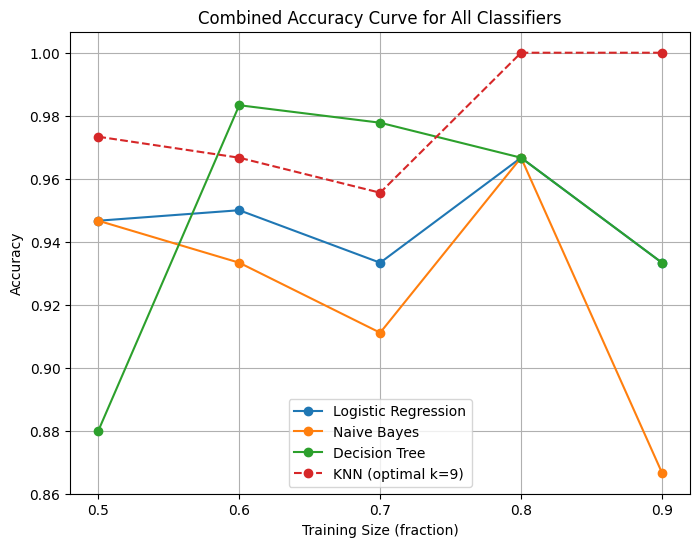

In [11]:
plt.figure(figsize=(8, 6))
for clf_name, accuracies in accuracy_results.items():
    plt.plot(training_sizes, accuracies, marker='o', label=clf_name)

plt.plot(training_sizes, optimal_knn_accuracies, marker='o', linestyle='--', label=f'KNN (optimal k={optimal_k})')

plt.title('Combined Accuracy Curve for All Classifiers')
plt.xlabel('Training Size (fraction)')
plt.ylabel('Accuracy')
plt.xticks(training_sizes)
plt.legend()
plt.grid(True)
plt.show()